# Configuration

In [1]:
import sys
import code
import os
import pickle

import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from tqdm import tqdm
import scipy.sparse
from scipy.sparse import csr_matrix
from gtfparse import read_gtf
from collections import defaultdict
from sklearn.metrics import auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

import networkx as nx
import dill



sys.path.append('/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/')

# 1. 加载 autoreload 扩展
%load_ext autoreload

# 2. 设置模式为 "2" (表示自动重载所有模块)
%autoreload 2

cell_type = "Panc1"
unibind_file = "/home/liyang/BioWuYan/dygmamba_project/data/cell_line/Panc1/unibind/Panc1_UniBind_search_rwt8gf39.tar.gz"

# Result

********** 开始读取数据...
正在读取压缩包: /home/liyang/BioWuYan/dygmamba_project/data/cell_line/Panc1/unibind/Panc1_UniBind_search_rwt8gf39.tar.gz ...
处理完成！
共提取了 5 个 TF 的数据。
总 Region 数量: 133469
  chrom   start     end    TF CellLine     SourceID
0  chr1  912085  912106  REST    PANC1  ENCSR000BJO
1  chr1  913717  913738  REST    PANC1  ENCSR000BJO
2  chr1  918790  918811  REST    PANC1  ENCSR000BJO
3  chr1  924766  924787  REST    PANC1  ENCSR000BJO
4  chr1  981649  981670  REST    PANC1  ENCSR000BJO
  CellLine      TF  PeakCount  Rank
0    PANC1    CTCF      42756   1.0
4    PANC1  TCF7L2      18010   2.0
2    PANC1    REST      16643   3.0
1    PANC1    ETS1       1940   4.0
3    PANC1  SREBF2        190   5.0
Top 40 AUC (Raw): 10.00
Top 40 AUC (Normalized): 0.8333

步骤 1: 过滤 Peaks (行)
  > 找到 59344 / 59344 个 peaks 至少有 1 个 TF 结合。

步骤 2: 过滤 TFs (列)
  > 找到 850 / 850 个 TFs 至少结合 1 个 peak。
  > 最终形状: (59344, 850)
**************************************************
Peak-Gene: 28737, 2000, edge:1650852
***

/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:436: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df_combined,
/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:451: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels)
/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:505: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df_combined,
/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:524: UserWarning: set_ticklabels() s

DyGMAMBA - Precision: 0.0014, Recall: 0.4509, FPR: 0.9843, AUC: 0.2333, F-beta: 0.0017
GLUE - Precision: 0.0000, Recall: 0.0000, FPR: 0.0076, AUC: 0.4962, F-beta: 0.0000
FigR - Precision: 0.0000, Recall: 0.0000, FPR: 0.0082, AUC: 0.4959, F-beta: 0.0000
Pando - Precision: 0.0000, Recall: 0.0000, FPR: 0.0300, AUC: 0.4850, F-beta: 0.0000
CellOracle - Precision: 0.0014, Recall: 0.4509, FPR: 0.9861, AUC: 0.2324, F-beta: 0.0017
LINGER - Precision: 0.0017, Recall: 0.3528, FPR: 0.7370, AUC: 0.3079, F-beta: 0.0021
GRaNIE - Precision: 0.0054, Recall: 0.0023, FPR: 0.0514, AUC: 0.4755, F-beta: 0.0043


/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:673: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Model', y='F-beta', data=result_dataframe.sort_values('F-beta', ascending=False), palette='viridis')
/tmp/ipykernel_6191/256846895.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Model', y='Precision', data=result_dataframe.sort_values('Precision', ascending=False), palette='viridis')


--- 1. 准备 ATAC Peak 数据 ---
未提供过滤列表，将使用 atac_adata 中所有的 Peaks。
ATAC Peaks 数量: 28799
--- 2. 准备 TF ChIP 数据 ---
TF ChIP Peaks 数量: 131034
--- 3. 计算重叠 (构建 Network) ---
构建了包含 18401 条边的 TF-Peak 网络。
--- 4. 转换为矩阵 (Matrix Construction) ---
--- 5. 封装为 AnnData ---
✅ 完成！生成的 AnnData 维度: (28799, 3) (Peaks x TFs)

步骤 1: 过滤 Peaks (行)
  > 找到 59344 / 59344 个 peaks 至少有 1 个 TF 结合。

步骤 2: 过滤 TFs (列)
  > 找到 850 / 850 个 TFs 至少结合 1 个 peak。
  > 最终形状: (59344, 850)
正在解析 Consensus Peaks 坐标...
共发现 1 个共有 TF，开始评估...
正在解析 Consensus Peaks 坐标...
共发现 1 个共有 TF，开始评估...
检测到冒号格式，正在统一为连字符格式...
正在解析 Consensus Peaks 坐标...
共发现 1 个共有 TF，开始评估...
检测到冒号格式，正在统一为连字符格式...
正在解析 Consensus Peaks 坐标...
共发现 1 个共有 TF，开始评估...
格式已是连字符（chr1-100-200），无需转换。
正在解析 Consensus Peaks 坐标...
共发现 1 个共有 TF，开始评估...


/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:901: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Method', y=score_col,
/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:901: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Method', y=score_col,
/tmp/ipykernel_6191/256846895.py:164: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=tf_region_df_combined,
/tmp/ipykernel_6191/256846895.py:199: FutureWarning: 

Passing `palette` wit

**************************************************
merged: 2894, benchmark peak gene: 2920,        dyg peak gene 49501
Peak-Gene: 2336,         1921, edge:2894
Merged Peak-Gene: 2336, 1921,         2894
DYGMAMBA Peak-Gene: 28737, 2000,         edge: 49501
Benchmark Peak-Gene: 2360,         1921, edge: 2920
**************************************************
正在筛选 100 个 Marker Genes...
正在合并预测数据与 Hi-C 数据...
共找到 147 个重叠的 Region-Gene 连接用于评估。
评估结果 (spearman): Correlation = 0.0536 (P-value = 5.19e-01)
**************************************************
merged: 968, benchmark peak gene: 2920,        dyg peak gene 922
Peak-Gene: 776,         769, edge:968
Merged Peak-Gene: 776, 769,         968
GLUE Peak-Gene: 920, 872,         edge: 922
Benchmark Peak-Gene: 2360,         1921, edge: 2920
**************************************************
正在筛选 100 个 Marker Genes...
正在合并预测数据与 Hi-C 数据...
共找到 45 个重叠的 Region-Gene 连接用于评估。
评估结果 (spearman): Correlation = -0.1147 (P-value = 4.53e-01)
********************

/home/liyang/BioWuYan/conda_env/dygmamba39/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/analysis/assess_region_gene.py:54: RuntimeWarning: invalid value encountered in scalar divide
  model_FPR = float(model_FP/(model_FP+model_TN))
/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/analysis/assess_region_gene.py:54: RuntimeWarning: invalid value encountered in scalar divide
  model_FPR = float(model_FP/(model_FP+model_TN))
/tmp/ipykernel_6191/256846895.py:236: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Method', y='Correlation', data=plot_data, palette='coolwarm')


                 Peak      Gene  value_bench  label  value_method
0  chr1-629321-630013  MTATP6P1   329.921082      1      0.965723
1  chr1-630819-631352  MTATP6P1   329.921082      1      0.956149
2  chr1-631924-632279  MTATP6P1   329.921082      1      0.969841
3  chr1-633915-634192  MTATP6P1   329.921082      1      0.969457
4  chr1-817498-819335     NOC2L    28.008671      1      0.999976
                 Peak      Gene  value_bench  label  value_method
0  chr1-629321-630013  MTATP6P1   329.921082      1      0.000000
1  chr1-630819-631352  MTATP6P1   329.921082      1      0.000000
2  chr1-631924-632279  MTATP6P1   329.921082      1      0.851188
3  chr1-633915-634192  MTATP6P1   329.921082      1      0.854820
4  chr1-817498-819335     NOC2L    28.008671      1      0.000000
                 Peak      Gene  value_bench  label  value_method
0  chr1-629321-630013  MTATP6P1   329.921082      1           0.0
1  chr1-630819-631352  MTATP6P1   329.921082      1           0.0
2  chr1-63

/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:1303: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(group['value_bench'], group['value_method'])
/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:1303: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(group['value_bench'], group['value_method'])
/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:1303: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(group['value_bench'], group['value_method'])
/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:1303: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(group['value_bench'], group['valu

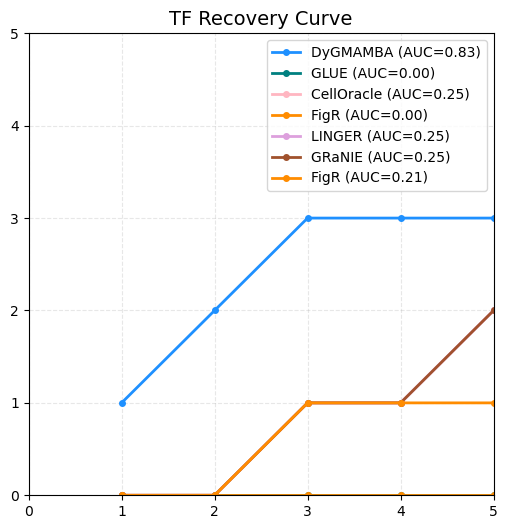

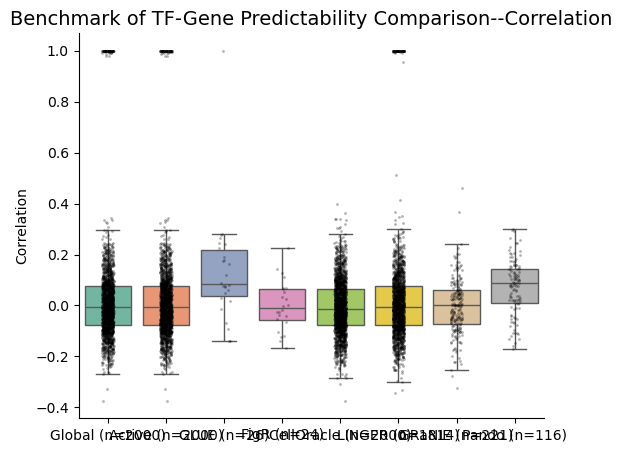

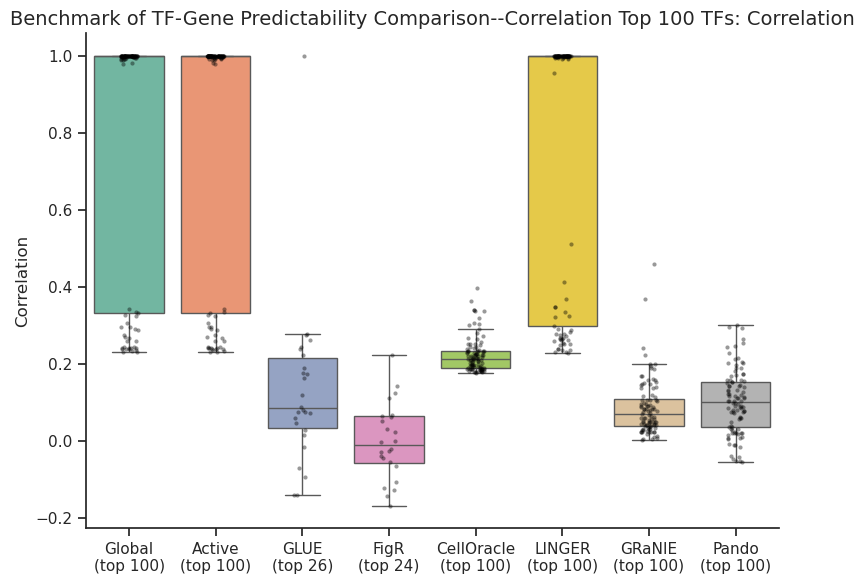

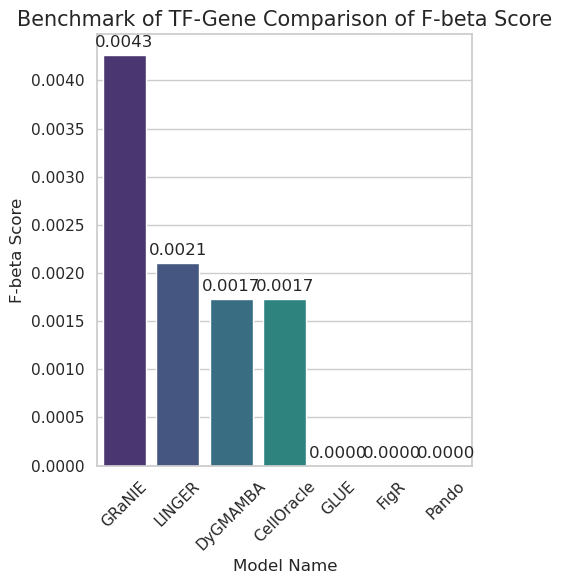

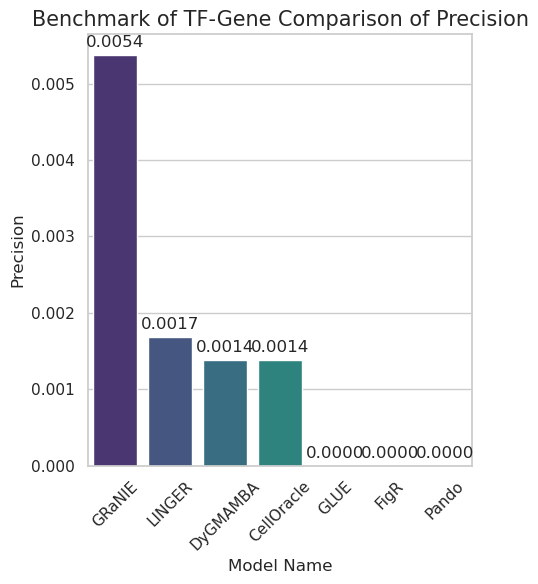

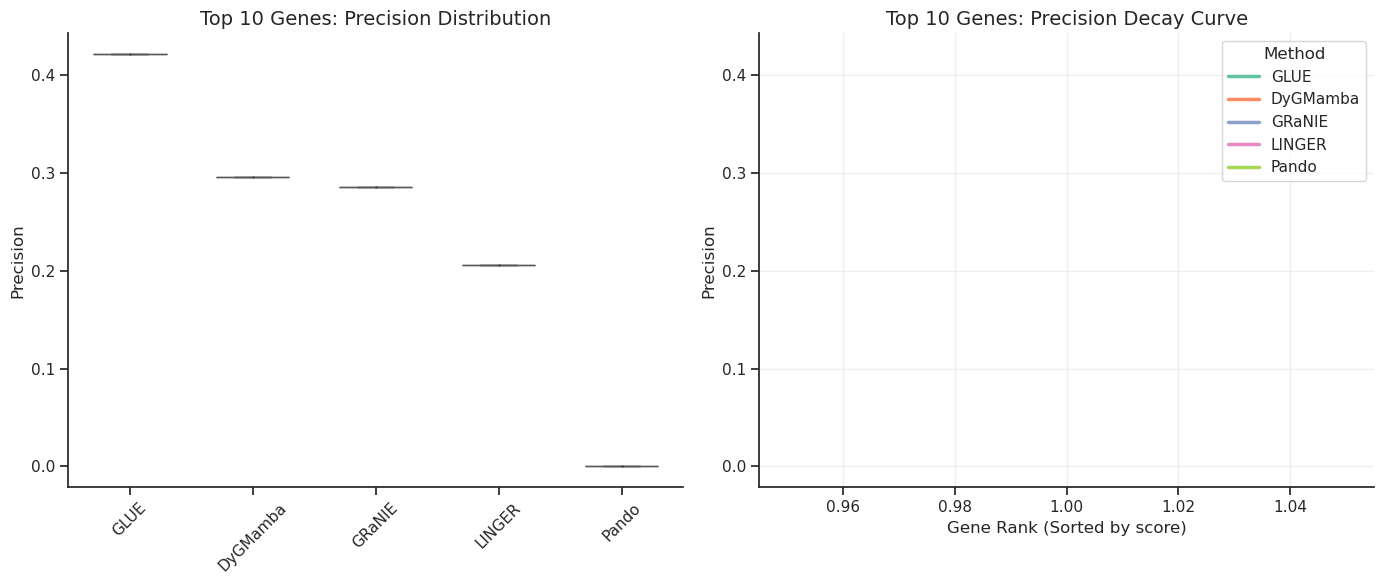

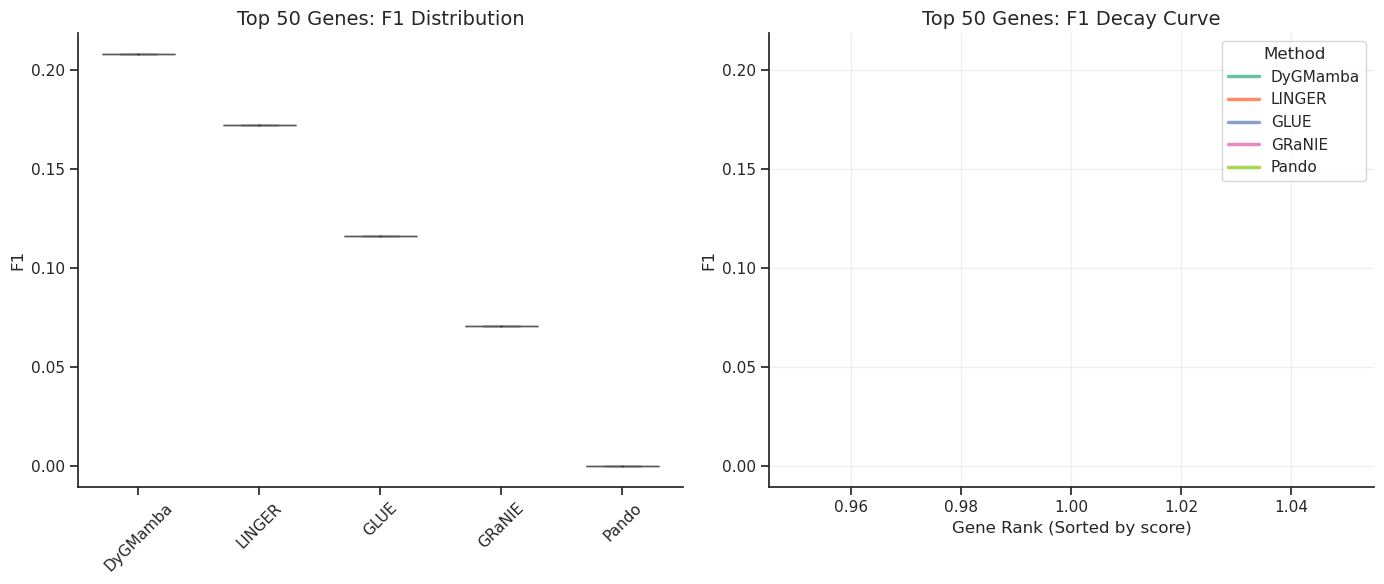

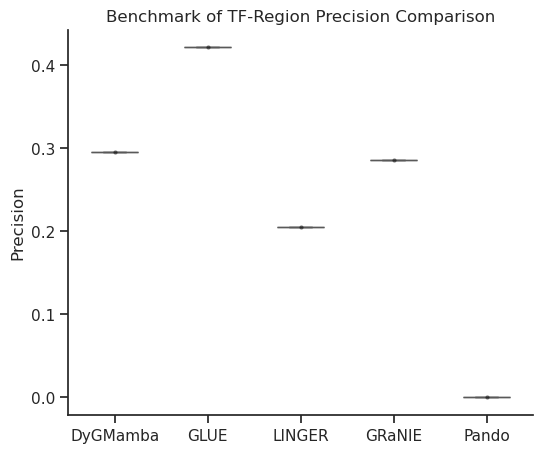

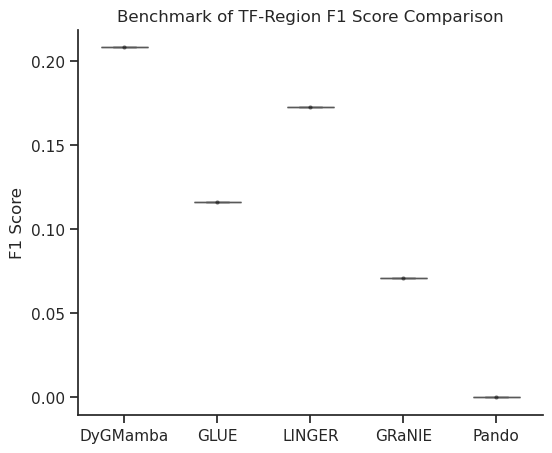

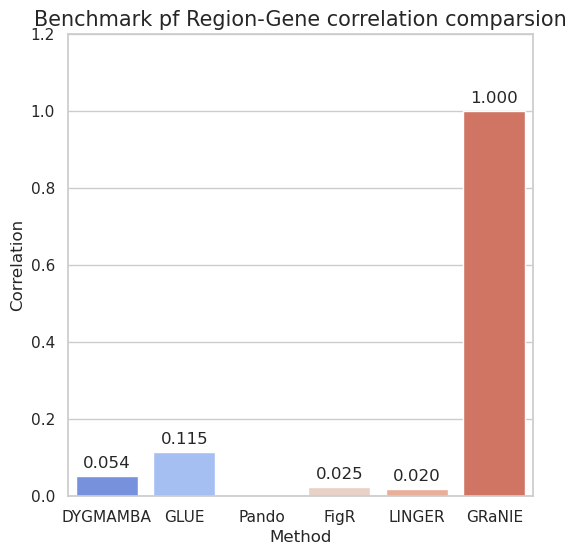

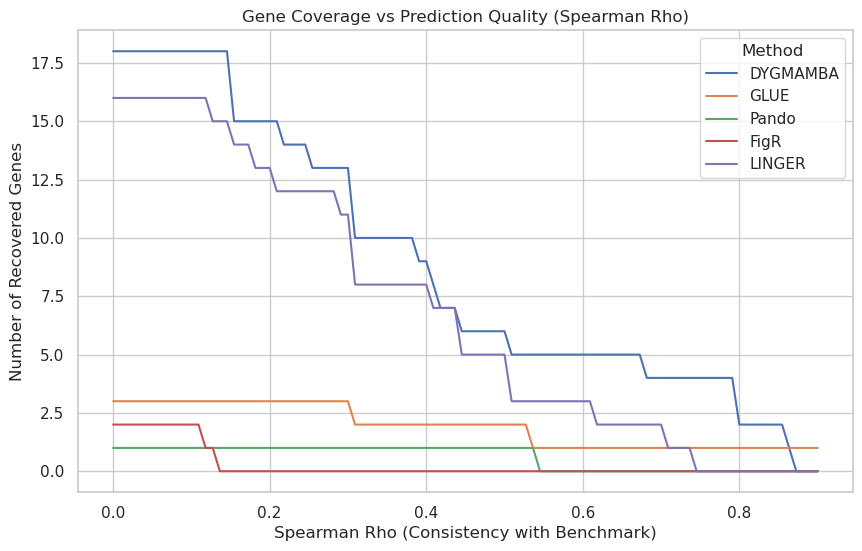

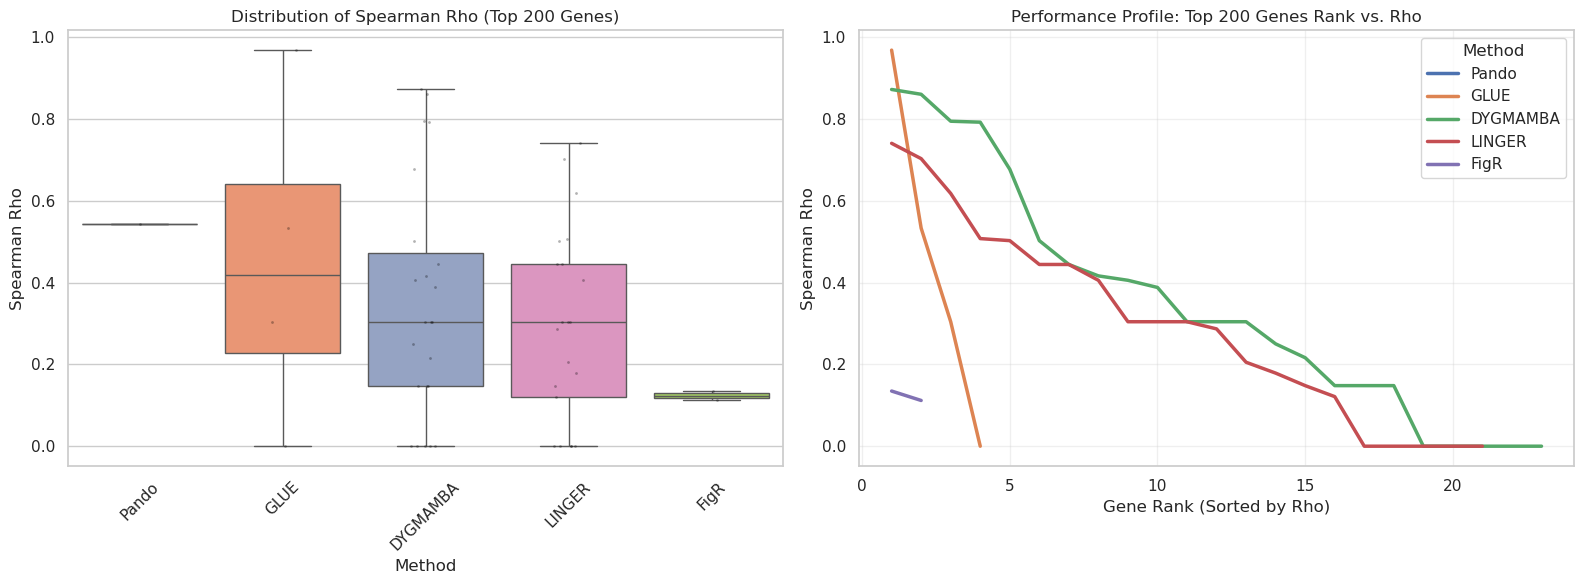

In [2]:
from pdata.data_read import read_unibind_file

data_path = "/home/liyang/BioWuYan/dygmamba_project/data/cell_line/" + cell_type + "/"

output_path = data_path + "benchmark/"

os.makedirs(output_path, exist_ok=True )

unibind_df_file = data_path + "benchmark/unibind_df.pkl"

model_result_path = data_path + "data_dyg/"

method_list = ["DyGMamba", "CellOracle", "FigR", "GLUE", "LINGER", "GRaNIE", "Pando"]

#############################################################################
#
# Unibind data processing
#
#############################################################################

unibind_df, count_region_df = read_unibind_file(unibind_file)

unibind_df["CellLine"] = unibind_df["CellLine"].str.split('_').str[0]
count_region_df["CellLine"] = count_region_df["CellLine"].str.split('_').str[0]

print(unibind_df.head())
print(count_region_df.head())

unibind_df.to_pickle(output_path + "unibind_df.pkl")
count_region_df.to_pickle(output_path + "count_region_df.pkl")


##############################################################################
#
# TF recovery
#
##############################################################################
from benchmark.benchmark_model import analysis_tf_recovery

analysis_tf_recovery(data_path, output_path, method_list)

##############################################################################
#
# TF-Gene
#
##############################################################################

from benchmark.benchmark_model import analysis_tf_gene_data, analysis_tf_gene_all_correlation, \
    plot_top_n_tf_comparison, dyg_tf_gene_result
    
from benchmark.benchmark_model import analysis_tf_gene_all_precision


tf_gene_grn, avg_active_tf_gene_grn, avg_global_tf_gene_grn = dyg_tf_gene_result(data_path, model_result_path)

result_dict = analysis_tf_gene_data( data_path, method_list )

analysis_tf_gene_all_correlation(output_path, result_dict)

###########################
# Top 100 correlation

# 1. 定义绘图顺序
my_order = ['Global', 'Active', 'GLUE', 'FigR', 'CellOracle', 'LINGER', 'GRaNIE', 'Pando']

plot_top_n_tf_comparison(result_dict, output_path, top_n=100, score_col='Correlation', my_order=my_order)

#############################
# Total correlation

result_dataframe = analysis_tf_gene_all_precision(data_path, output_path, method_list)

############################
# figure plot

sns.set_theme(style="whitegrid")
plt.figure(figsize=(5, 6))

ax = sns.barplot(x='Model', y='Precision', data=result_dataframe.sort_values('Precision', ascending=False), palette='viridis')

plt.title('Benchmark of TF-Gene Comparison of Precision', fontsize=15)
plt.xlabel('Model Name', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.xticks(rotation=45) 

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.4f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.tight_layout()
plt.savefig(output_path + 'Benchmark of TF-Gene Comparison of Precision.png', dpi=1200, bbox_inches='tight')

##############################################################################
#
# TF-Region
#
##############################################################################


from benchmark.benchmark_model import analysis_tf_region
###################################
# Benchmark

f_score = 0.1

tf_region_result = analysis_tf_region(unibind_df_file, data_path, f_score, method_list)


###################################
# 
from benchmark.benchmark_model import plot_top_n_comparison

# # 1. 准备数据字典
# tf_region_result = {
#     "DYGMAMBA": dyg_results,
#     "GLUE": glue_results,
#     "LINGER": linger_results,
#     "GRaNIE": granie_results,
#     "Pando": pando_results
# }

# 2. 调用函数
# 例如：对比前 10 个基因的 Precision
top_results = plot_top_n_comparison(
    method_dict=tf_region_result, 
    output_file=output_path + 'Benchmark of TF-Region Comparison of Top 10 Precision.png',
    top_n=10, 
    score_col="Precision"
)

# 2. 调用函数
# 例如：对比前 50 个基因的 Precision
top_results = plot_top_n_comparison(
    method_dict= tf_region_result, 
    output_file= output_path + 'Benchmark of TF-Region Comparison of Top 50 F1 Score.png',
    top_n= 50, 
    score_col= "F1"
)


###########################
# Boxplot
###########################
# precisioin

analysis_type = "Precision"
tf_region_df = []

for method_name, df in tf_region_result.items():

    tf_region_df.append(df[[analysis_type, 'Method']])

tf_region_df_combined = pd.concat(tf_region_df, ignore_index=True)

# ==========================
# @ 绘制箱形图
# ==========================
sns.set_theme(style="ticks")
plt.figure(figsize=(6, 5))

ax = sns.boxplot(data=tf_region_df_combined, 
                 x='Method',    # x轴放分组标签
                 y=analysis_type,        # y轴放数值
                 palette="Set2", # 配色方案
                 width=0.5)     # 箱子宽度

sns.stripplot(data=tf_region_df_combined, x='Method', y=analysis_type, 
              color='black', size=3, alpha=0.5, jitter=True)

plt.title("Benchmark of TF-Region Precision Comparison")
plt.ylabel("Precision")
plt.xlabel("") # 去掉 x 轴的 'Method' 字样，因为标签已经很清楚了
sns.despine()  # 去掉上方和右侧的边框，更符合学术规范

plt.savefig(output_path + 'Benchmark of TF-Region Comparison of Precision.png', dpi=1200, bbox_inches='tight')


################################
# F1 score

analysis_type = "F1"
tf_region_df = []

for method_name, df in tf_region_result.items():

    tf_region_df.append(df[[analysis_type, 'Method']])

tf_region_df_combined = pd.concat(tf_region_df, ignore_index=True)

# =============================
# @ 绘制箱形图
# =============================
sns.set_theme(style="ticks")
plt.figure(figsize=(6, 5))

ax = sns.boxplot(data=tf_region_df_combined, 
                 x='Method',    # x轴放分组标签
                 y=analysis_type,        # y轴放数值
                 palette="Set2", # 配色方案
                 width=0.5)     # 箱子宽度

sns.stripplot(data=tf_region_df_combined, x='Method', y=analysis_type, 
              color='black', size=3, alpha=0.5, jitter=True)

plt.title("Benchmark of TF-Region F1 Score Comparison")
plt.ylabel("F1 Score")
plt.xlabel("") # 去掉 x 轴的 'Method' 字样，因为标签已经很清楚了
sns.despine()  # 去掉上方和右侧的边框，更符合学术规范

plt.savefig(output_path + 'Benchmark of TF-Region Comparison of F1 Score.png', dpi=1200, bbox_inches='tight')

##############################################################################
#
# Region-Gene
#
##############################################################################

from benchmark.benchmark_model import analysis_region_gene, evaluate_r2g_benchmark, \
    plot_recovery_curves, plot_top_n_methods_comparison

results, method_data, benchmark_peak_gene_df = analysis_region_gene(data_path, output_path, method_list)

#################################
# Correlation

plot_data = results.T.reset_index()
plot_data.columns = ['Method', 'Correlation']

# 2. 绘图
plt.figure(figsize=(6, 6))
sns.set_style("whitegrid") # 设置清爽的白色网格背景

ax = sns.barplot(x='Method', y='Correlation', data=plot_data, palette='coolwarm')

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.3f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.title("Benchmark pf Region-Gene correlation comparsion", fontsize=15)
plt.ylim(0, max(plot_data['Correlation']) * 1.2) # 给上方数值留点空间

plt.savefig(output_path + 'Benchmark of Region-Gene Correlation Comparison.png', dpi=1200, bbox_inches='tight')


#############################
# score analysis

corr_df, metrics_df = evaluate_r2g_benchmark(benchmark_peak_gene_df, method_data)

corr_df['Abs_Spearman_Rho'] = corr_df['Spearman_Rho'].abs()

# 调用
plot_recovery_curves(corr_df, 
                     output_file=output_path + 'Benchmark of Recovery Curve of Region-Gene Prediction.png',
                     compared_method='Abs_Spearman_Rho')

plot_top_n_methods_comparison(corr_df, 
                              output_file=output_path + 'Benchmark of Region-Gene Comparison of Top 200 Spearman Rho.png',
                              top_n=200, compare_method='Abs_Spearman_Rho')
